[![Wiki](https://img.shields.io/badge/-Wiki-blue?style=flat-square&logo=github)](./wiki/Home.md)
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/neurovium/CorticalBlueprintRNN/blob/main/StatisticalAnalysis/6_6_2_sttc_corr.ipynb)

*See the [wiki](./wiki/Home.md) for the input-data schema and statistical methods, or the [top-level repo README](../README.md) for the broader project.*

## Import Libraries

In [124]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import friedmanchisquare

## Set Constants

In [125]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

metric = 'Accuracy' # choose the metric: Accuracy, Assortativity, Entropy, Loss, Modularity, SmallWorldness, Validation_Accuracy, Validation_Loss

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name = f'/content/data/simu/{base}'


task1_file_dir = f'{folder_name}/Task1/{metric}_raw.csv'
task2_file_dir = f'{folder_name}/Task2/{metric}_raw.csv'
task3_file_dir = f'{folder_name}/Task3/{metric}_raw.csv'

## Load Dataset

In [126]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
!ls /content/drive/MyDrive/ISP

Papers	simu.zip


In [128]:
!unzip /content/drive/MyDrive/ISP/simu.zip -d /content/data

Archive:  /content/drive/MyDrive/ISP/simu.zip
replace /content/data/__MACOSX/simu/._5_6_8_sttc-precision_sign+? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/simu/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._5_6_8_sttc-corr_sign+? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._5_3_4_sttc-corr? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._5_3_4_sttc-corr_sign+? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._5_3_4_sttc-precision_sign+? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._6_6_2_sttc-precision_sign+? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._6_6_2_sttc-precision? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/__MACOSX/simu/._6_6_2_sttc-corr? [y]es, [n]o, [A]l

In [133]:
print(os.listdir("/content/data/simu"))

['5_6_8_sttc-corr', 'rcc.ipynb', '5_3_4_sttc-corr_sign+', '5_6_8_sttc-precision_sign+', '6_6_2_sttc-corr', '6_6_2_sttc-corr_sign+', '.DS_Store', 'plotting.ipynb', '6_6_2_sttc-precision_sign+', '5_3_4_sttc-precision', '5_3_4_sttc-corr', '6_6_2_sttc-precision', '5_6_8_sttc-precision', '5_3_4_sttc-precision_sign+', '5_6_8_sttc-corr_sign+']


## Predefined Functions

In [134]:
def check_disturbution_difference(df, models):
  same = []
  for i in range(len(models)):
    for j in range (i + 1, len(models)):
      stat, p = mannwhitneyu(df[models[i]], df[models[j]], alternative="two-sided")
      print(f'Model {models[i]} vs Model {models[j]}')
      print(f'stat = {stat}, p = {p}')
      if p > 0.05:
        # print('Same distribution (fail to reject H0)')
        same.append((models[i], models[j]))
      # else:
        # print('Different distribution (reject H0)')
      # print()
  return same

In [135]:
def calculate_confidence_interval(data, confidence_level=0.95):
    n = len(data)
    acc_task = data.dropna().values
    mean_acc = np.mean(acc_task)
    sem = stats.sem(acc_task)  # standard error of the mean
    ci95 = stats.t.interval(0.95, df=n-1, loc=mean_acc, scale=sem)

    return mean_acc, ci95

In [136]:
def naive_disturbution_comparision_across_tasks(df1, df2, df3, models, metric_name):
  for model in models:
    plt.figure(figsize=(6,4))

    plt.hist(df1[model], bins=10, alpha=0.5, label="Task 1", density=True)
    plt.hist(df2[model], bins=10, alpha=0.5, label="Task 2", density=True)
    plt.hist(df3[model], bins=10, alpha=0.5, label="Task 3", density=True)

    plt.title(f"{metric_name} Distribution for {model}")
    plt.xlabel(f"{metric_name}")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [138]:
def task_box_plots(dfs, metric_name):
  task_names = ["Task 1", "Task 2", "Task 3"]

  for i, (df, name) in enumerate(zip(dfs, task_names)):
    task1_long = df.melt(var_name="Model", value_name=metric_name)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Model", y=metric_name, data=task1_long)

    plt.xticks(rotation=45)
    plt.title(f"{metric_name} Distributions of Models on {task_names[i]}")
    plt.xlabel("Model Variants")
    plt.ylabel(metric_name)
    plt.tight_layout()
    plt.show()

In [139]:
def draw_model_disturbutions(df, models, metric_name):
  for model in models:

    plt.figure(figsize=(6,4))

    plt.hist(df[model], bins=10, alpha=0.5, density=True)

    plt.title(f"{metric_name} Distribution for {model}")
    plt.xlabel(metric_name)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Accuracy Analysis

In [140]:
print(os.listdir(folder_name))

['RCC1', 'Task1.png', 'metrics_SD.csv', 'Task2', 'Task2.png', 'config.txt', 'Task1', '.DS_Store', 'Task3.png', 'Task3', 'RCC3', 'metrics.csv', 'RCC2']


In [141]:
df1 = pd.read_csv(task1_file_dir)
df2 = pd.read_csv(task2_file_dir)
df3 = pd.read_csv(task3_file_dir)

In [142]:
df1.drop('simulation', axis=1, inplace=True)
df2.drop('simulation', axis=1, inplace=True)
df3.drop('simulation', axis=1, inplace=True)

In [143]:
df1.head(20)

,W*D*C,WD*C,WDC,WD*,WD,W,W*D*C*,WD*C*,W*DC*,W!D*C,W!D*C*
0,1.000000,0.624609,0.633984,0.625195,0.637500,0.617188,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,0.626562,0.627539,1.000000,0.628906,0.628125,1.000000,1.000000,0.630859,0.629883,1.000000
2,0.694531,0.629492,0.622070,0.630859,0.620313,0.621484,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.762500,0.633984,0.620898,1.000000,0.627539,0.629883,1.000000,0.632617,1.000000,1.000000,1.000000
4,1.000000,0.611914,0.628906,0.859961,0.631250,0.624609,0.701367,0.625586,1.000000,0.606055,0.634375
5,1.000000,0.627539,0.619727,0.627930,0.615820,0.628906,1.000000,0.632227,1.000000,1.000000,1.000000
6,1.000000,0.630664,0.626367,0.624023,0.622461,0.621094,1.000000,0.617578,1.000000,1.000000,1.000000
7,1.000000,0.627148,0.625195,1.000000,0.627539,0.628711,1.000000,0.624414,1.000000,1.000000,1.000000
8,0.730273,0.627930,0.625781,1.000000,0.620508,0.625391,1.000000,0.624023,1.000000,1.000000,1.000000
9,0.632031,0.625781,0.625586,0.625781,0.624414,0.620898,1.000000,1.000000,1.000000,1.000000,1.000000


In [144]:
models = df1.columns

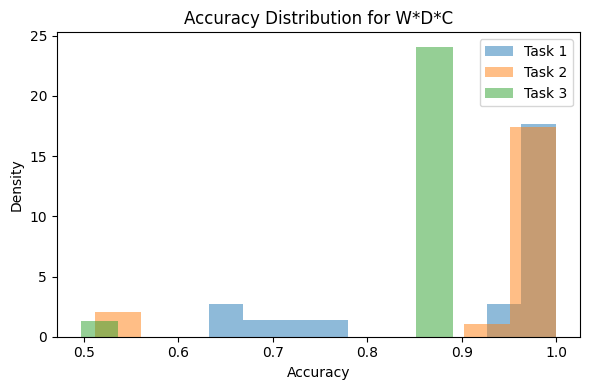

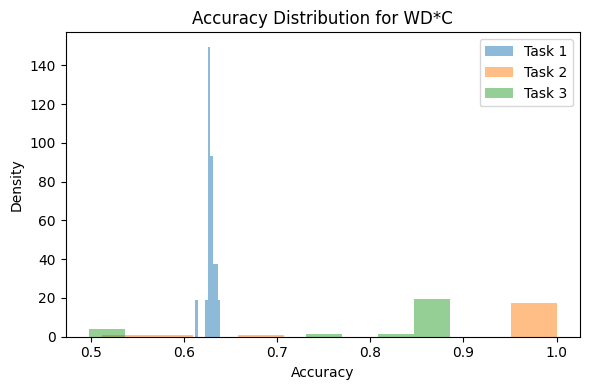

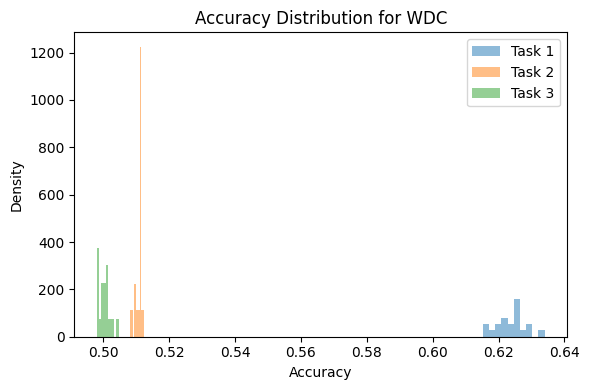

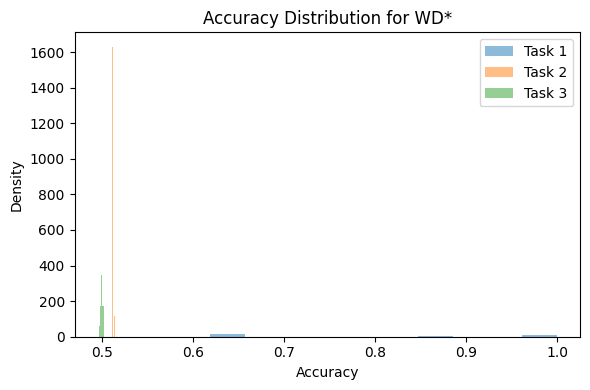

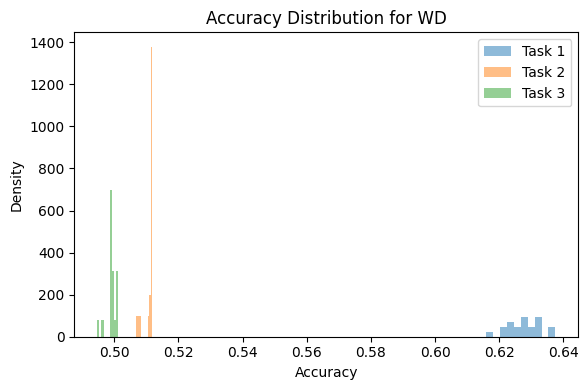

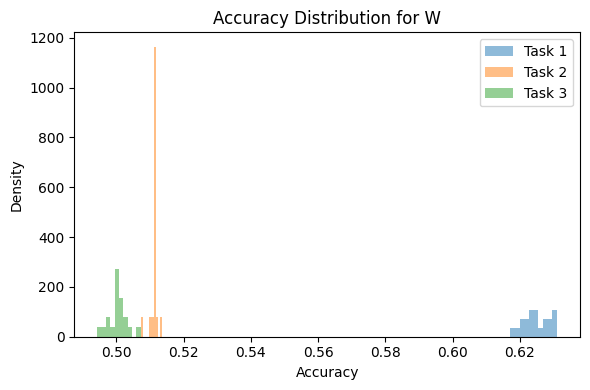

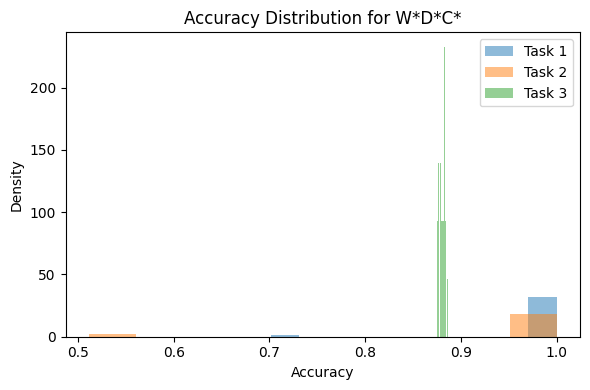

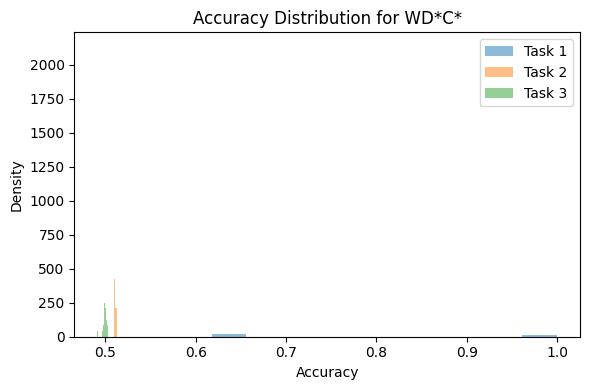

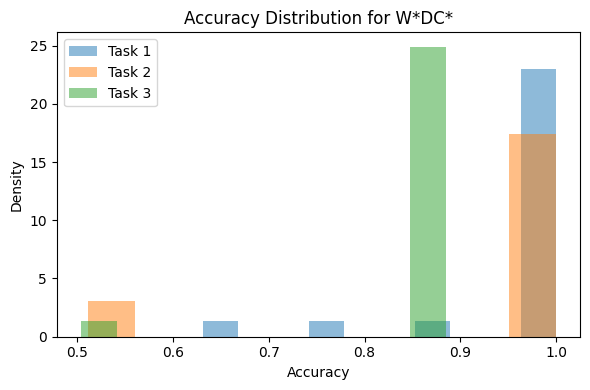

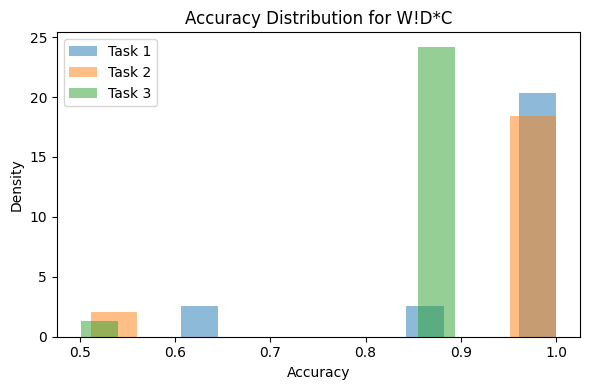

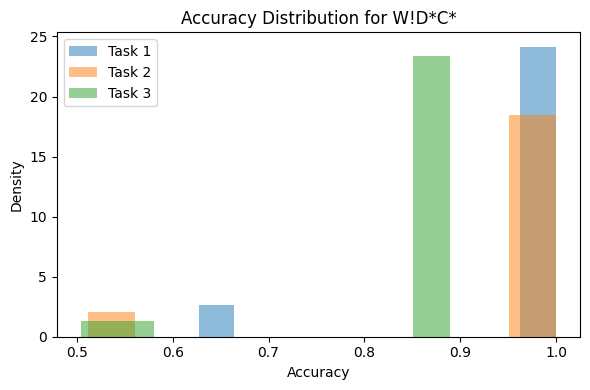

In [145]:
naive_disturbution_comparision_across_tasks(df1, df2, df3, models, 'Accuracy')

In [146]:
for model in models:

  mean_acc1, ci95_1 = calculate_confidence_interval(df1[model])
  mean_acc2, ci95_2 = calculate_confidence_interval(df2[model])
  mean_acc3, ci95_3 = calculate_confidence_interval(df3[model])

  print(f"----------Model: {model}-----------")
  print(f"Mean accuracy Task 1: {mean_acc1:.3f}")
  print(f"95% CI Task 1: ({ci95_1[0]:.3f}, {ci95_1[1]:.3f})\n")
  print(f"Mean accuracy Task 2: {mean_acc2:.3f}")
  print(f"95% CI Task 2: ({ci95_2[0]:.3f}, {ci95_2[1]:.3f})\n")
  print(f"Mean accuracy Task 3: {mean_acc3:.3f}")
  print(f"95% CI Task 3: ({ci95_3[0]:.3f}, {ci95_3[1]:.3f})\n")


----------Model: W*D*C-----------
Mean accuracy Task 1: 0.917
95% CI Task 1: (0.853, 0.981)

Mean accuracy Task 2: 0.948
95% CI Task 2: (0.878, 1.018)

Mean accuracy Task 3: 0.865
95% CI Task 3: (0.824, 0.906)

----------Model: WD*C-----------
Mean accuracy Task 1: 0.628
95% CI Task 1: (0.626, 0.631)

Mean accuracy Task 2: 0.939
95% CI Task 2: (0.869, 1.009)

Mean accuracy Task 3: 0.812
95% CI Task 3: (0.747, 0.876)

----------Model: WDC-----------
Mean accuracy Task 1: 0.624
95% CI Task 1: (0.622, 0.626)

Mean accuracy Task 2: 0.511
95% CI Task 2: (0.510, 0.511)

Mean accuracy Task 3: 0.500
95% CI Task 3: (0.500, 0.501)

----------Model: WD*-----------
Mean accuracy Task 1: 0.787
95% CI Task 1: (0.700, 0.874)

Mean accuracy Task 2: 0.512
95% CI Task 2: (0.511, 0.512)

Mean accuracy Task 3: 0.500
95% CI Task 3: (0.499, 0.501)

----------Model: WD-----------
Mean accuracy Task 1: 0.628
95% CI Task 1: (0.625, 0.630)

Mean accuracy Task 2: 0.511
95% CI Task 2: (0.510, 0.512)

Mean accurac

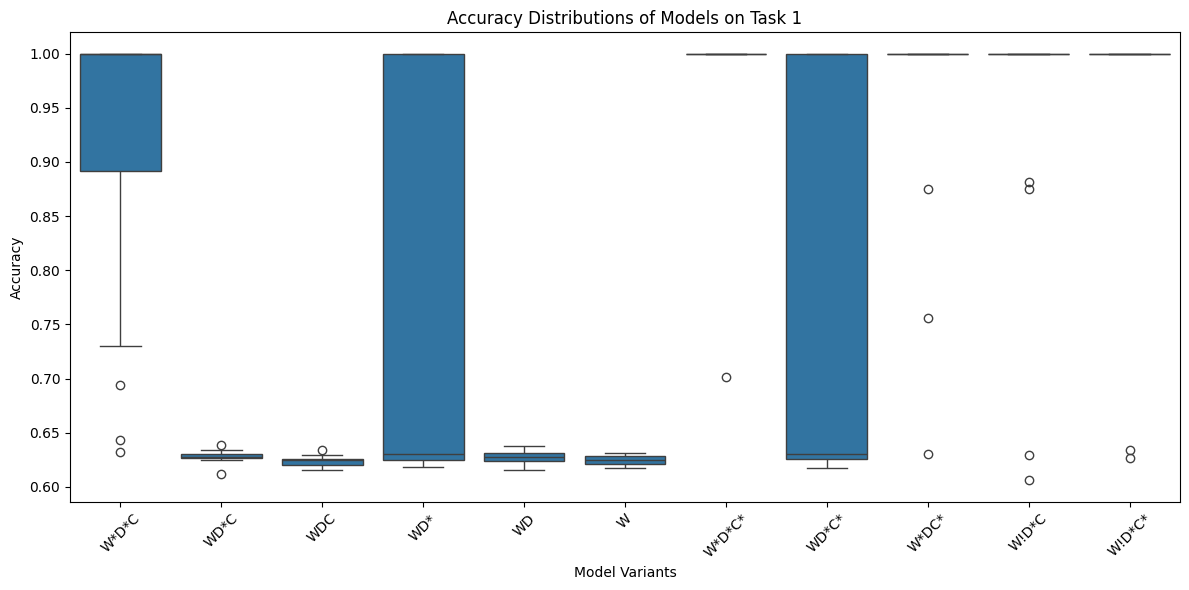

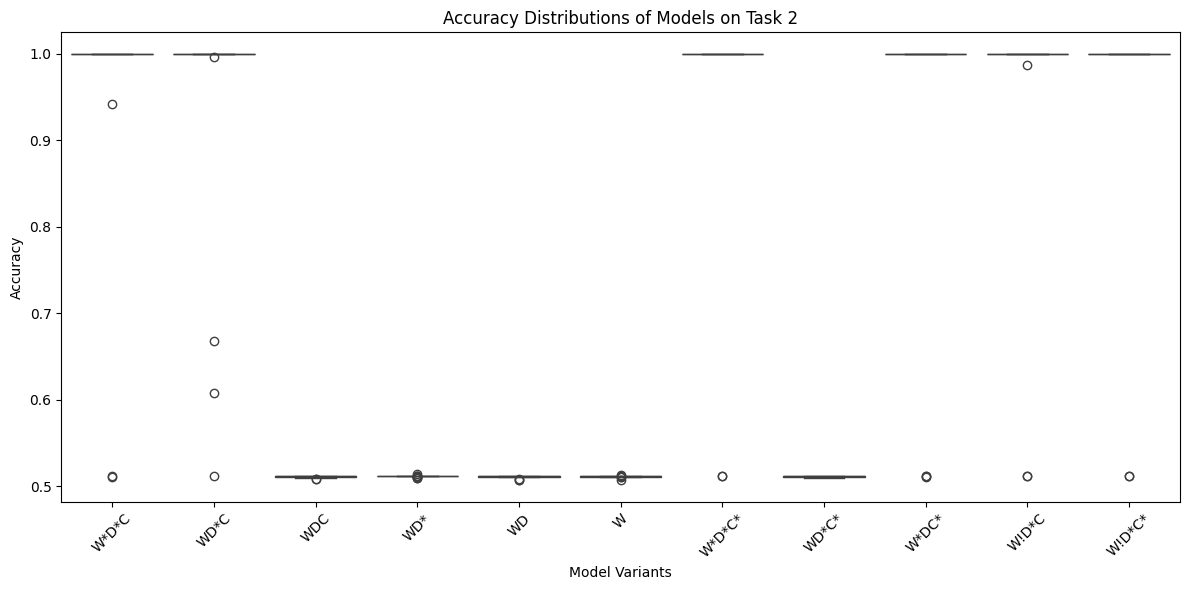

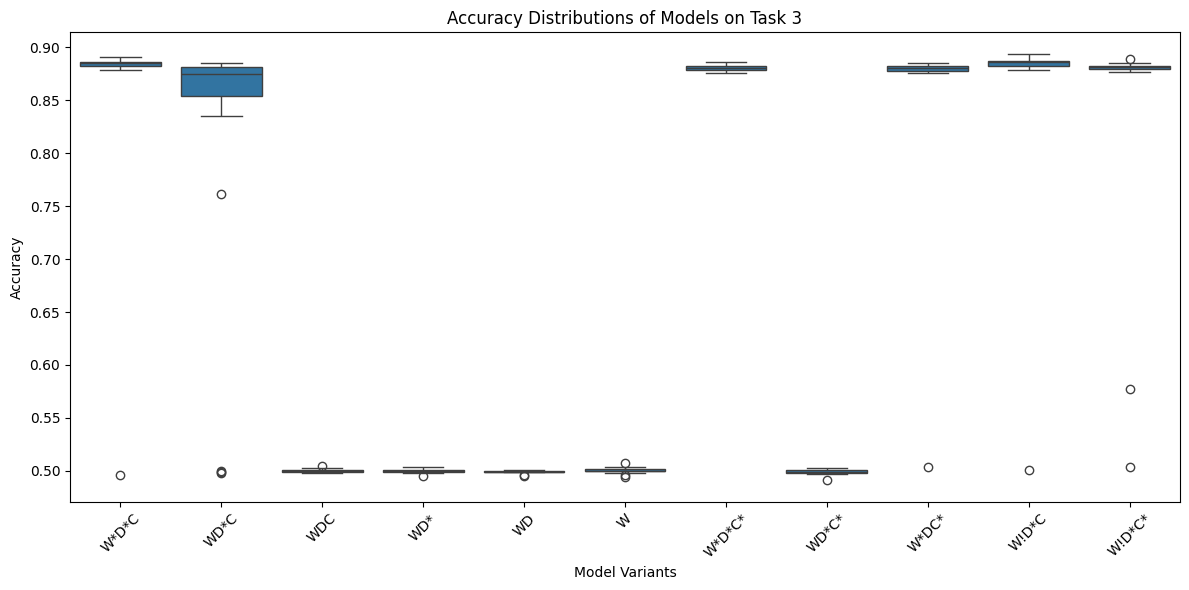

In [147]:
task_box_plots([df1, df2, df3], "Accuracy")

/tmp/ipython-input-498221133.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


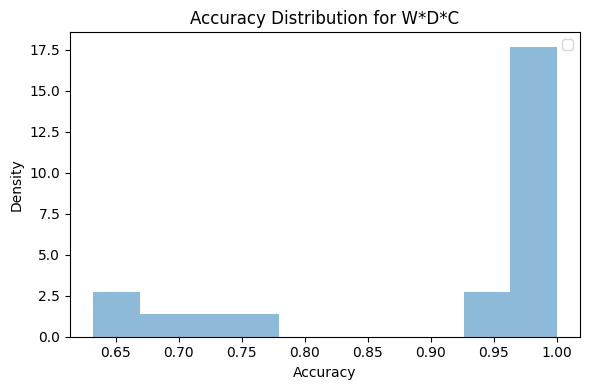

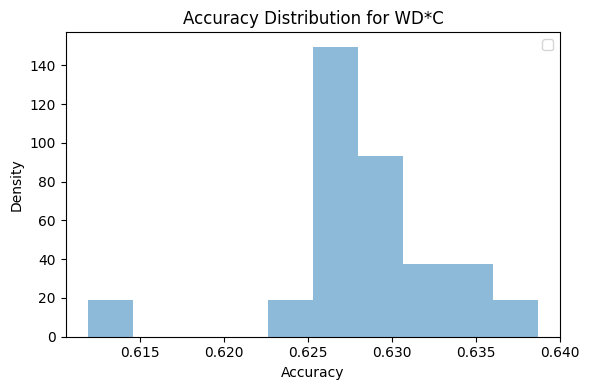

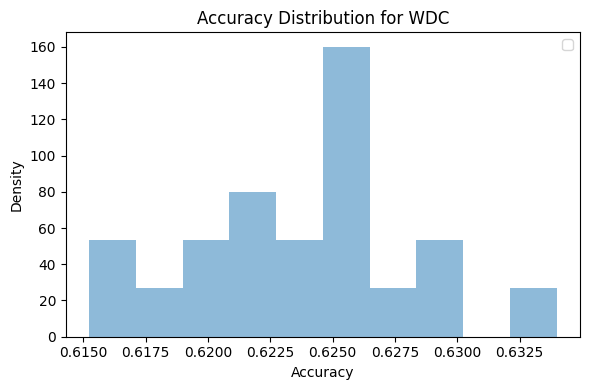

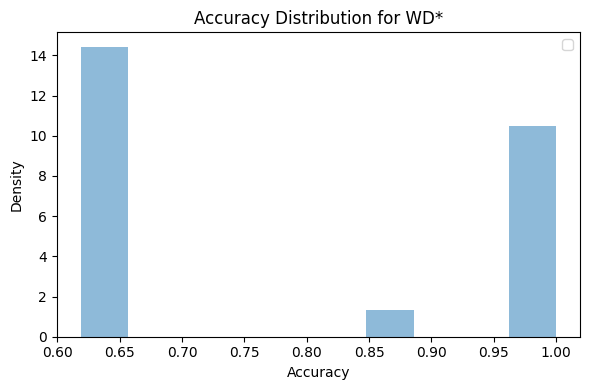

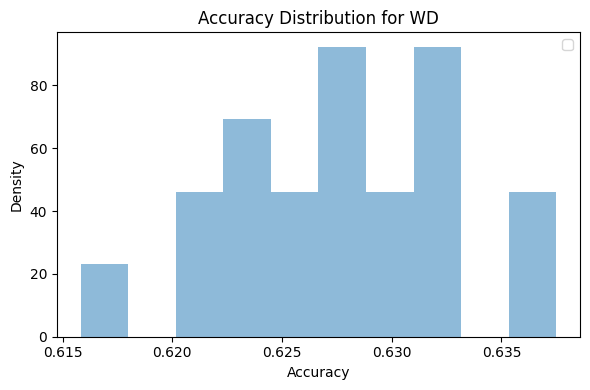

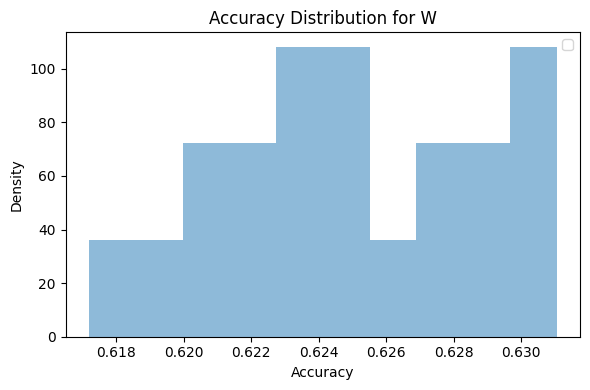

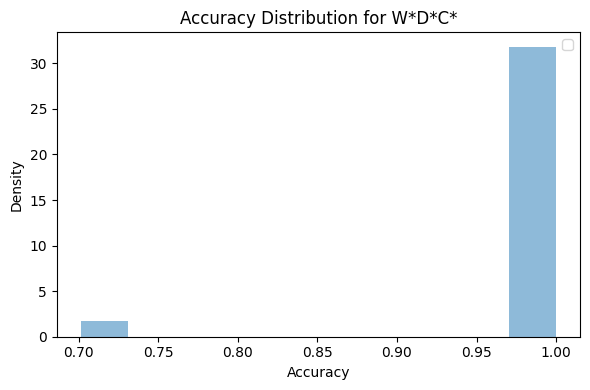

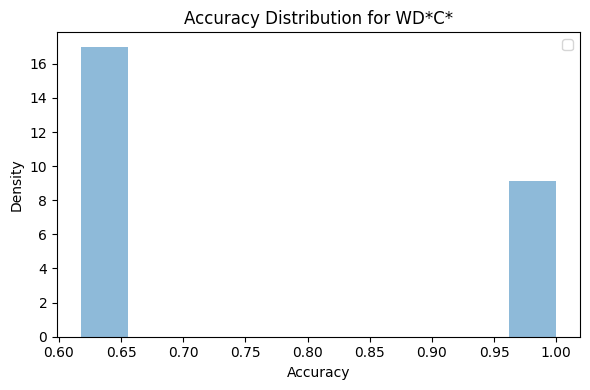

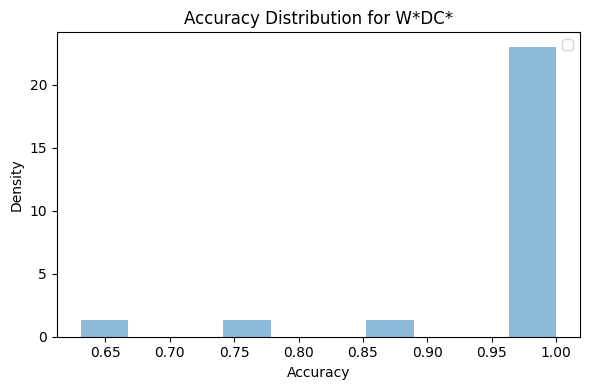

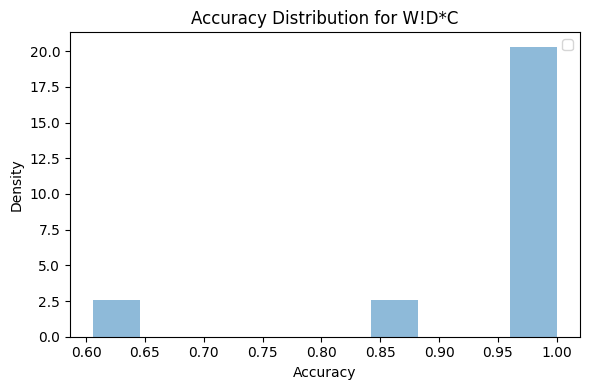

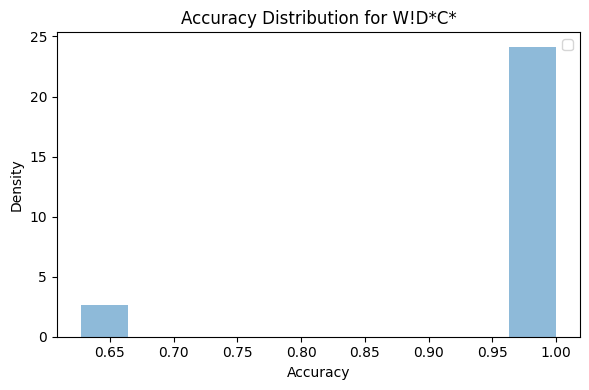

In [148]:
draw_model_disturbutions(df1, models, 'Accuracy')

In [149]:
stat1, p1 = kruskal(df1['W!D*C'], df1['W!D*C*'], df1['W'], df1['W*D*C'], df1['W*D*C*'], df1['W*DC*'], df1['WD'], df1['WD*'], df1['WD*C'], df1['WD*C*'], df1['WDC'])  # list_of_samples = [sample1, sample2, ..., sample11]
print(f'Task 1: {stat1}, {p1}')

stat2, p2 = kruskal(df2['W!D*C'], df2['W!D*C*'], df2['W'], df2['W*D*C'], df2['W*D*C*'], df2['W*DC*'], df2['WD'], df2['WD*'], df2['WD*C'], df2['WD*C*'], df2['WDC'])
print(f'Task 2: {stat2}, {p2}')

stat3, p3 = kruskal(df3['W!D*C'], df3['W!D*C*'], df3['W'], df3['W*D*C'], df3['W*D*C*'], df3['W*DC*'], df3['WD'], df3['WD*'], df3['WD*C'], df3['WD*C*'], df3['WDC'])
print(f'Task 3: {stat3}, {p3}')

Task 1: 140.06017037320012, 4.0964206182678477e-25
Task 2: 157.78387547157624, 9.287146935613016e-29
Task 3: 160.81168445865617, 2.2029113281232366e-29


In [150]:
same_model_accuracies_1 = check_disturbution_difference(df1, models)
same_model_accuracies_2 = check_disturbution_difference(df2, models)
same_model_accuracies_3 = check_disturbution_difference(df3, models)

Model W*D*C vs Model WD*C
stat = 397.0, p = 6.35602883335682e-08
Model W*D*C vs Model WDC
stat = 399.0, p = 4.653571872945986e-08
Model W*D*C vs Model WD*
stat = 287.0, p = 0.011412071631301817
Model W*D*C vs Model WD
stat = 396.0, p = 7.387463840333483e-08
Model W*D*C vs Model W
stat = 400.0, p = 3.995358749418445e-08
Model W*D*C vs Model W*D*C*
stat = 140.5, p = 0.022360848043512155
Model W*D*C vs Model WD*C*
stat = 303.5, p = 0.002900126065174305
Model W*D*C vs Model W*DC*
stat = 161.5, p = 0.17648719883956754
Model W*D*C vs Model W!D*C
stat = 174.0, p = 0.380688532776273
Model W*D*C vs Model W!D*C*
stat = 156.0, p = 0.1075814397269352
Model WD*C vs Model WDC
stat = 323.5, p = 0.0008749023080461889
Model WD*C vs Model WD*
stat = 157.0, p = 0.24831238566240876
Model WD*C vs Model WD
stat = 225.0, p = 0.5073259929987154
Model WD*C vs Model W
stat = 296.0, p = 0.009772742038963398
Model WD*C vs Model W*D*C*
stat = 0.0, p = 1.1266570353724972e-08
Model WD*C vs Model WD*C*
stat = 161.5, 